In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data Understanding

In [2]:
df = pd.read_csv(r"C:\Users\hp\OneDrive\Desktop\Customer-Churn-Prediction\Data\Raw.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [12]:
df["TotalCharges"].value_counts().head(10)

TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
Name: count, dtype: int64

In [13]:
df["TotalCharges"].astype(str).str.strip().eq("").sum()

np.int64(11)

In [14]:
df[df["TotalCharges"].astype(str).str.strip() == ""]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


# Data Cleaning

There are no missing values/duplicates and only we need to convert TotalChargers column from object to numeric.

In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

 errors="coerce" : "Convert valid values to numbers, and if something cannot be converted, turn it into NaN."

In [16]:
df["TotalCharges"].isnull().sum()

np.int64(11)

we'll simply remove those 11 records because they represent customers with zero tenure and don't provide usable TotalCharges

In [17]:
df.dropna(subset=["TotalCharges"], inplace=True)

In [18]:
df.shape

(7032, 21)

In [19]:
df.drop("customerID", axis=1, inplace=True)

customerID isn't useful for predicting churn.
It's an identifier, not a meaningful customer characteristic.

In [20]:
df.shape

(7032, 20)

In [21]:
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [22]:
df.isnull().sum().sum()

np.int64(0)

# EDA

#### 1. Target distribution

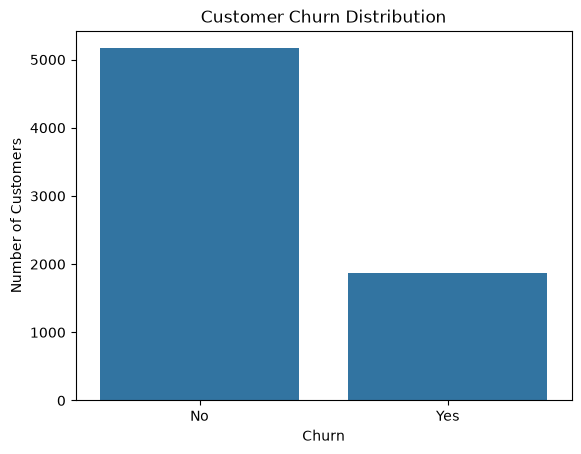

In [23]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [24]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

#### 2. Churn vs Contract

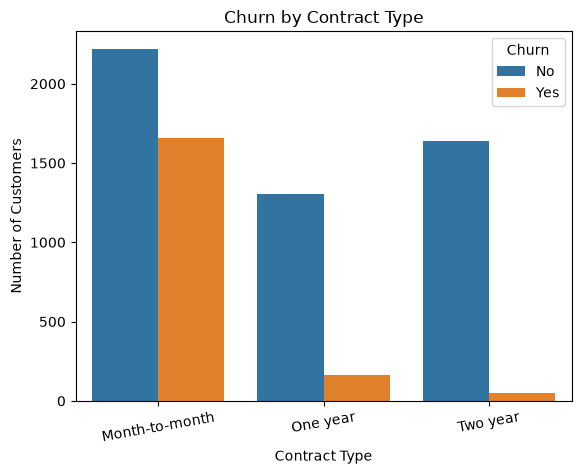

In [25]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=10)
plt.show()

In [26]:
# Actual churn rate
pd.crosstab(df["Contract"],df["Churn"],normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


#### 3. Churn vs Monthly Charges

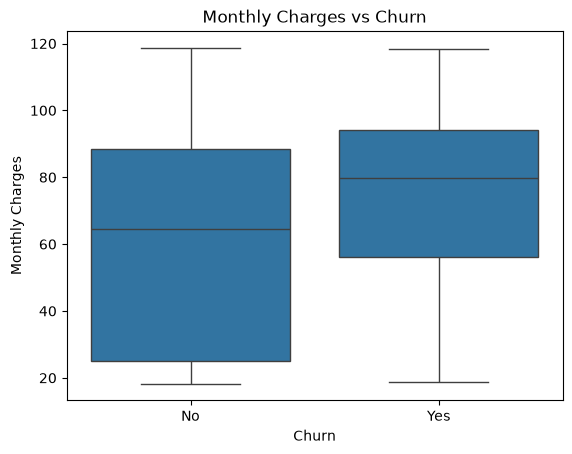

In [27]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

#### 4. Churn vs Tenure

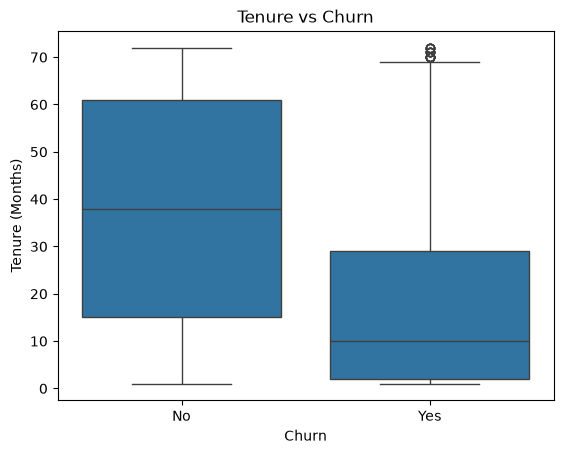

In [28]:
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

Target is imbalanced.

That's important because later we should not rely only on accuracy. We'll pay attention to Recall, Precision, F1-score and ROC-AUC.

#### 5.Internet Service vs Churn

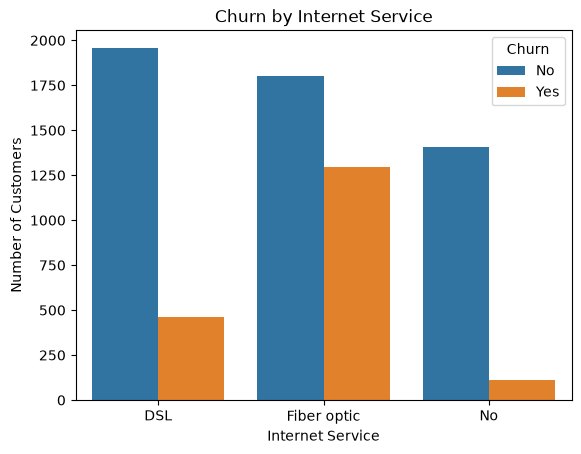

In [29]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [30]:
pd.crosstab(df["InternetService"],df["Churn"],normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


#### 6. Payment Method vs Churn

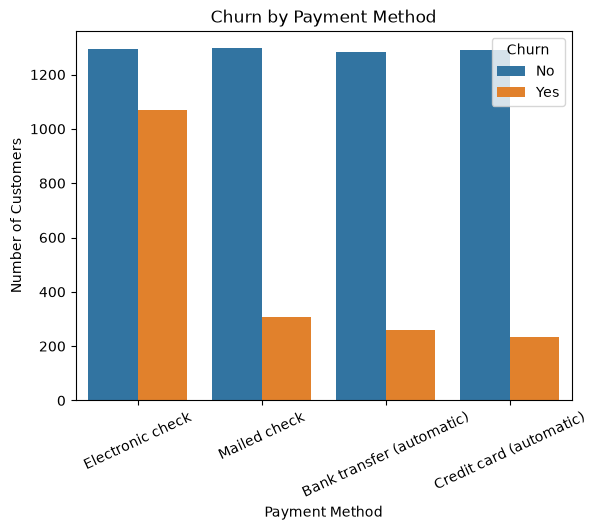

In [31]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)
plt.show()

In [32]:
pd.crosstab(df["PaymentMethod"],df["Churn"],normalize="index") * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


#### 7. Online Security & Tech Support vs Churn

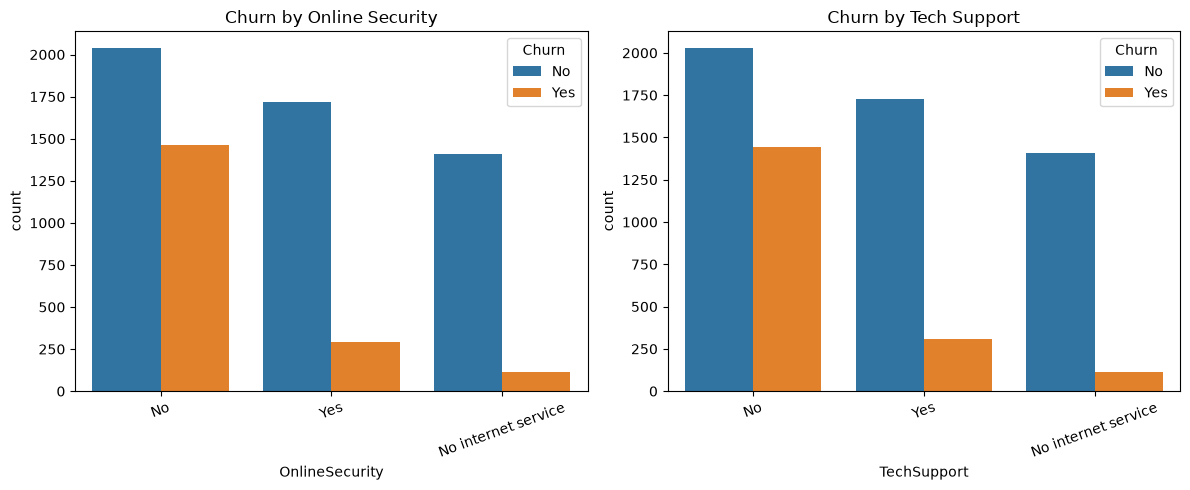

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="OnlineSecurity", hue="Churn", ax=axes[0])
axes[0].set_title("Churn by Online Security")
axes[0].tick_params(axis="x", rotation=20)
sns.countplot(data=df, x="TechSupport", hue="Churn", ax=axes[1])
axes[1].set_title("Churn by Tech Support")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

In [34]:
print("Online Security:")
print(pd.crosstab(df["OnlineSecurity"],df["Churn"],normalize="index") * 100)
print("\nTech Support:")
print(pd.crosstab(df["TechSupport"],df["Churn"],normalize="index") * 100)

Online Security:
Churn                       No        Yes
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes                  85.359801  14.640199

Tech Support:
Churn                       No        Yes
TechSupport                              
No                   58.352535  41.647465
No internet service  92.565789   7.434211
Yes                  84.803922  15.196078


#### 8. Senior Citizen vs Churn

In [35]:
pd.crosstab(df["SeniorCitizen"],df["Churn"],normalize="index") * 100

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


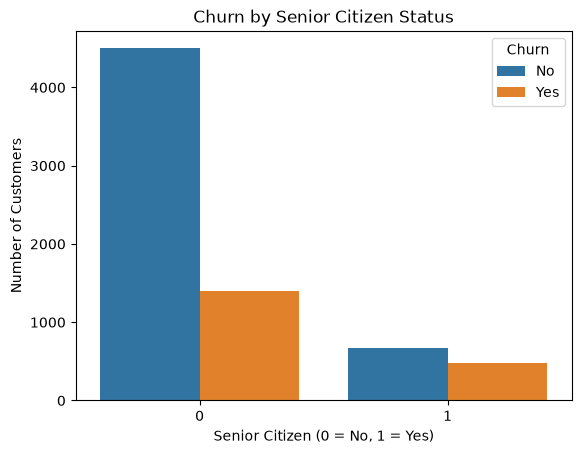

In [36]:
sns.countplot(data=df, x="SeniorCitizen", hue="Churn")
plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

In [37]:
df.to_csv(r"C:\Users\hp\OneDrive\Desktop\Customer-Churn-Prediction\Data\Clean_data.xls", index=False)

# Machine Learning process

In [38]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [39]:
X.shape, y.shape

((7032, 19), (7032,))

In [40]:
X.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [41]:
categorical_cols = X.select_dtypes(include="object").columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(X[col].unique())


gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:


C:\Users\hp\AppData\Local\Temp\ipykernel_16756\4270339086.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingTV:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

StreamingMovies:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Contract:
<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

PaperlessBilling:
<ArrowStringArray

In [42]:
y.value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

#### Splitting data

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [44]:
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (5625, 19)
Testing set: (1407, 19)


In [45]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object", "string"]).columns
print("Numerical columns:")
print(list(numeric_cols))
print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


#### Preprocessing

In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_cols),("cat", OneHotEncoder(handle_unknown="ignore",drop="first"), categorical_cols)])

### Model training

#### 1. Logistic Regression

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", LogisticRegression(max_iter=1000,random_state=42))])

In [48]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [49]:
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_lr, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred_lr, pos_label="Yes"))
print("ROC-AUC  :", roc_auc_score((y_test == "Yes").astype(int),y_prob_lr))

Accuracy : 0.8052594171997157
Precision: 0.6515151515151515
Recall   : 0.5748663101604278
F1 Score : 0.6107954545454546
ROC-AUC  : 0.8360739966143986


In [51]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [52]:
print(confusion_matrix(y_test, y_pred_lr))

[[918 115]
 [159 215]]


#### 2. Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[("preprocessor", preprocessor),("classifier", RandomForestClassifier(n_estimators=300,random_state=42,
            class_weight="balanced"))])

In [54]:
random_forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [55]:
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [56]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label="Yes"))
print("ROC-AUC  :", roc_auc_score((y_test == "Yes").astype(int),y_prob_rf))

Accuracy : 0.7725657427149965
Precision: 0.5613636363636364
Recall   : 0.660427807486631
F1 Score : 0.6068796068796068
ROC-AUC  : 0.8204375915639511


In [57]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

          No       0.87      0.81      0.84      1033
         Yes       0.56      0.66      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407



In [58]:
print(confusion_matrix(y_test, y_pred_rf))

[[840 193]
 [127 247]]


#### Test threshold

In [59]:
y_pred_rf_040 = (y_prob_rf >= 0.40).astype(int)
y_test_binary = (y_test == "Yes").astype(int)
print("Precision:", precision_score(y_test_binary, y_pred_rf_040))
print("Recall   :", recall_score(y_test_binary, y_pred_rf_040))
print("F1 Score :", f1_score(y_test_binary, y_pred_rf_040))

Precision: 0.5061728395061729
Recall   : 0.767379679144385
F1 Score : 0.6099893730074389


# Explainable AI

In [65]:
import shap

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [66]:
rf_preprocessor = random_forest_model.named_steps["preprocessor"]
rf_classifier = random_forest_model.named_steps["classifier"]

In [67]:
X_test_transformed = rf_preprocessor.transform(X_test)

In [68]:
X_test_transformed.shape

(1407, 30)

In [69]:
feature_names = rf_preprocessor.get_feature_names_out()
print(len(feature_names))
print(feature_names)

30
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Male' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaperlessBilling_Yes' 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check']


In [70]:
explainer = shap.TreeExplainer(rf_classifier)

In [71]:
shap_values = explainer.shap_values(X_test_transformed)

In [72]:
type(shap_values)

numpy.ndarray

#### Global XAI

In [73]:
import numpy as np
print(np.array(shap_values).shape)

(1407, 30, 2)


In [75]:
shap_values_churn = shap_values[:, :, 1]
print(shap_values_churn.shape)

(1407, 30)


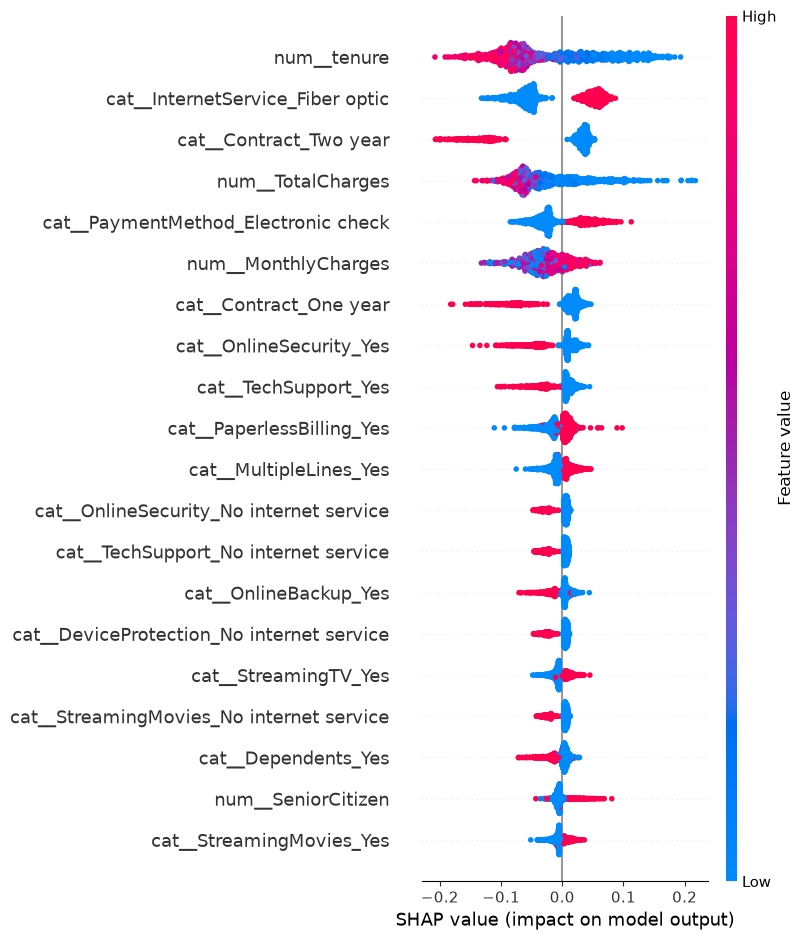

In [76]:
shap.summary_plot(shap_values_churn,X_test_transformed,feature_names=feature_names)

#### Locaal XAI

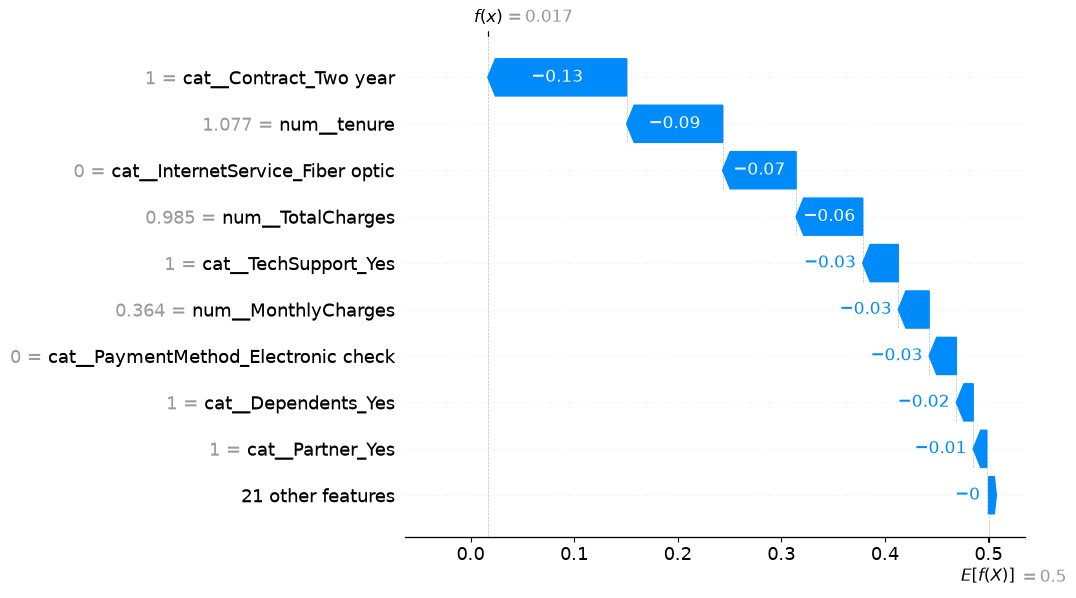

In [77]:
customer_index = 0
shap.waterfall_plot(shap.Explanation(
        values=shap_values_churn[customer_index],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[customer_index],
        feature_names=feature_names))

#### High-risk customer

In [78]:
# Find the customer with the highest predicted churn probability
high_risk_index = np.argmax(y_prob_rf)
print("Test index:", high_risk_index)
print("Churn probability:", y_prob_rf[high_risk_index])
print("\nCustomer details:")
print(X_test.iloc[high_risk_index])

Test index: 31
Churn probability: 1.0

Customer details:
gender                          Male
SeniorCitizen                      0
Partner                           No
Dependents                        No
tenure                             1
PhoneService                     Yes
MultipleLines                     No
InternetService          Fiber optic
OnlineSecurity                    No
OnlineBackup                      No
DeviceProtection                  No
TechSupport                       No
StreamingTV                       No
StreamingMovies                   No
Contract              Month-to-month
PaperlessBilling                 Yes
PaymentMethod       Electronic check
MonthlyCharges                  69.1
TotalCharges                    69.1
Name: 3682, dtype: object


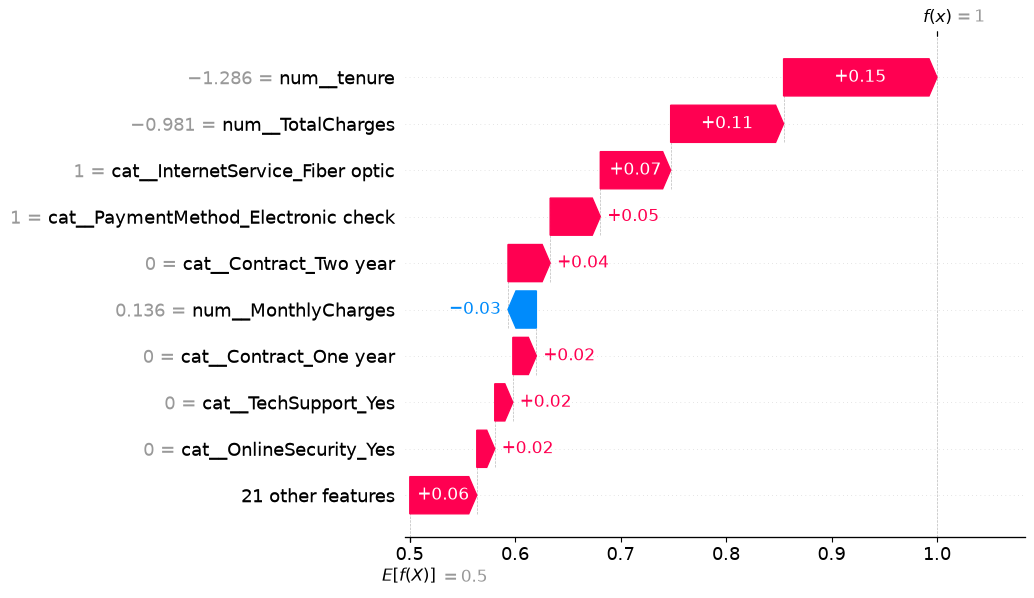

In [79]:
high_risk_shap = shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_churn[high_risk_index],
        base_values=explainer.expected_value[1],
        data=X_test_transformed[high_risk_index],
        feature_names=feature_names))

In [80]:
FINAL_THRESHOLD = 0.40
def predict_churn(customer_data):
    probability = random_forest_model.predict_proba(customer_data)[:, 1][0]
    if probability >= FINAL_THRESHOLD:
        prediction = "Yes"
    else:
        prediction = "No"
    if probability >= 0.70:
        risk = "High Risk"
    elif probability >= 0.40:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"
    return prediction, probability, risk

In [81]:
prediction, probability, risk = predict_churn(X_test.iloc[[high_risk_index]])
print("Prediction:", prediction)
print("Churn Probability:", probability)
print("Risk Level:", risk)

Prediction: Yes
Churn Probability: 1.0
Risk Level: High Risk


### Model Deployment

In [88]:
import joblib
import os
model_path = r"C:\Users\hp\OneDrive\Desktop\Customer-Churn-Prediction\Model_Deployment\customer_churn_model.pkl"
joblib.dump(random_forest_model, model_path)
print("Saved successfully")
print("File size:", os.path.getsize(model_path), "bytes")

Saved successfully
File size: 59660402 bytes


In [89]:
import joblib
test_model = joblib.load(model_path)
print("Model loaded successfully")
print("Model type:", type(test_model))

Model loaded successfully
Model type: <class 'sklearn.pipeline.Pipeline'>
